# Model Comparison

A notebook to compare the parameters of the different fitted brain models.

In [28]:
# Load the parameters

from hbnm.io import Data
input_dir = '/home/frank/HBNM/data/'
output_dir = '/home/frank/HBNM/outputs/'
data = Data(input_dir, output_dir)

### Load Models

This code block is where all of model parameters are loaded into arrays. 

This facilitates plotting and statistical comparison between parameter sets.

In [29]:
# Demirtas Models
fin = data.load('demirtas_neuron_2019.hdf5', from_output=False)
theta_heterogeneous_Demirtas = fin['apprx_posterior_heterogeneous'][:5]
theta_homogeneous_Demirtas = fin['apprx_posterior_homogeneous'][:3]
fin.close()

# Homogeneous Models
fin = data.load('NTHC_Homo_Group/iteration_30.hdf5', from_output=True)
theta_homogeneous_NTHC = fin['theta'][:]
fin.close()

fin = data.load('Homogenous/iteration_20.hdf5', from_output=True)
theta_homogeneous_M1 = fin['theta'][:]
fin.close()

# Heterogeneous Models
fin = data.load('TEHC_Myelin_Group/iteration_50.hdf5', from_output=True)
theta_heterogeneous_TEHC = fin['theta'][:]
fin.close()
fin = data.load('NTHC_Myelin_Group/iteration_51.hdf5', from_output=True)
theta_heterogeneous_NTHC = fin['theta'][:]
fin.close()

fin = data.load('Heterogeneous_Dem_Range/iteration_53.hdf5', from_output=True)
theta_heterogeneous_HCP_M2 = fin['theta'][:]
fin.close()

fin = data.load('Heterogeneous_Old_Range/iteration_35.hdf5', from_output=True)
theta_heterogeneous_HCP_M1 = fin['theta'][:]
fin.close()

fin = data.load('NTS_Myelin_Group/iteration_50.hdf5', from_output=True)
theta_heterogeneous_NTS = fin['theta'][:]
fin.close()

fin =  data.load('TIS_Myelin_Group/iteration_50.hdf5', from_output=True)
theta_heterogeneous_TIS = fin['theta'][:]
fin.close()

fin = data.load('M3_NTS_Myelin_Group/iteration_31.hdf5', from_output=True)
theta_heterogeneous_M3_NTS = fin['theta'][:]
fin.close()

fin = data.load('M3_NTHC_Myelin_Group/iteration_31.hdf5', from_output=True)
theta_heterogeneous_M3_NTHC = fin['theta'][:]
fin.close()

# M4 Models
# fin = data.load('M4_NTS_Myelin_Group/iteration_31.hdf5', from_output=True)
# theta_heterogeneous_M4_NTS = fin['theta'][:]
# fin.close()

fin = data.load('M4_NTHC_Myelin_Group/iteration_31.hdf5', from_output=True)
theta_heterogeneous_M4_NTHC = fin['theta'][:]
fin.close()

# M5 Models
fin = data.load('M5_NTS_Myelin_Group/iteration_31.hdf5', from_output=True)
theta_heterogeneous_M5_NTS = fin['theta'][:]
fin.close()

fin = data.load('M5_NTHC_Myelin_Group/iteration_31.hdf5', from_output=True)
theta_heterogeneous_M5_NTHC = fin['theta'][:]
fin.close()

# M5 Models with hPMC
fin = data.load('M5_NTHC_Myelin_hPMC/iteration_31.hdf5', from_output=True)
theta_heterogeneous_M5_NTHC_hPMC = fin['theta'][:]
fin.close()

fin = data.load('M5_NTS_Myelin_hPMC/iteration_31.hdf5', from_output=True)
theta_heterogeneous_M5_NTS_hPMC = fin['theta'][:]
fin.close()

### Plotting

In [30]:
import matplotlib.pyplot as plt
import numpy as np
def get_param_means(model_array):
    """
    Compute the mean of each parameter across all particles for a model.
    Assumes shape (n_params, n_particles).
    """
    return np.mean(model_array, axis=1)

def get_param_stds(model_array):
    """
    Compute the std of each parameter across all particles for a model.
    Assumes shape (n_params, n_particles).
    """
    return np.std(model_array, axis=1)

def plot_model_comparison_box(models, param_names):
    """
    Plot box plots comparing parameter distributions across models, with individual data points overlaid.
    """
    n_params = len(param_names)
    n_models = len(models)
    
    fig, axes = plt.subplots(1, n_params, figsize=(15, 6), sharey=False)
    if n_params == 1:
        axes = [axes]
    
    # Colors for different models
    colors = plt.cm.Set1(np.linspace(0, 1, n_models))
    
    for param_idx, param_name in enumerate(param_names):
        ax = axes[param_idx]
        
        # Prepare data for this parameter across all models
        data_for_boxplot = []
        tick_labels = []
        
        for model_name, model_array in models.items():
            # Extract parameter values for this parameter (assumes shape n_params x n_particles)
            param_values = model_array[param_idx, :]
            data_for_boxplot.append(param_values)
            tick_labels.append(model_name)
        
        # Create box plot
        box_plot = ax.boxplot(data_for_boxplot, tick_labels=tick_labels, patch_artist=True, 
                             showfliers=False, widths=0.6)
        
        # Color the boxes
        for patch, color in zip(box_plot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        # Overlay individual data points with jitter
        for i, (model_name, param_values) in enumerate(zip(tick_labels, data_for_boxplot)):
            # Add some jitter to x-coordinates for better visibility
            x_jitter = np.random.normal(i + 1, 0.04, size=len(param_values))
            ax.scatter(x_jitter, param_values, alpha=0.6, s=20, color=colors[i], 
                      edgecolors='black', linewidth=0.5, zorder=3)
        
        # Formatting
        ax.set_title(f'{param_name}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Parameter Value' if param_idx == 0 else '')
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    plt.suptitle('Parameter Comparison Across Models (Box Plots with Individual Points)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

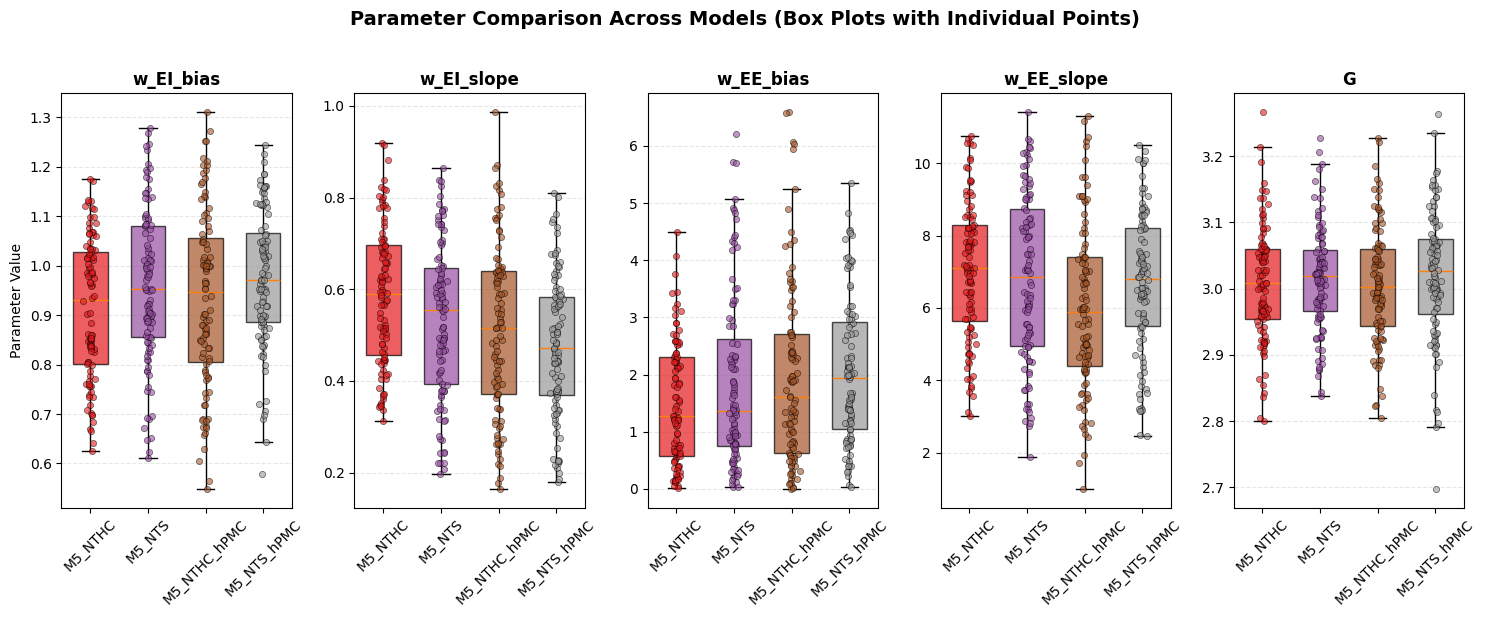

In [31]:
# Parameter order for plotting:
param_names = ['w_EI_bias', 'w_EI_slope', 'w_EE_bias', 'w_EE_slope', 'G']

# Models to Compare
model_dict = {
    # 'NTHC': theta_heterogeneous_NTHC,
    # 'NTS': theta_heterogeneous_NTS,
    # 'M3_NTS': theta_heterogeneous_M3_NTS,
    # 'M3_NTHC': theta_heterogeneous_M3_NTHC,
    # 'M4_NTS': theta_heterogeneous_M4_NTS,
    # 'M4_NTHC': theta_heterogeneous_M4_NTHC,
    'M5_NTHC': theta_heterogeneous_M5_NTHC,
    'M5_NTS': theta_heterogeneous_M5_NTS,
    'M5_NTHC_hPMC': theta_heterogeneous_M5_NTHC_hPMC,
    'M5_NTS_hPMC': theta_heterogeneous_M5_NTS_hPMC,
}

# Plot the comparison
plot_model_comparison_box(model_dict, param_names)

In [32]:
# homogeneous_param_names = ['w_EI','w_EE','G']
# homogeneous_model_dict = {
#     'NTHC': theta_homogeneous_NTHC,
#     'Demirtas': theta_homogeneous_Demirtas,
#     'M1': theta_homogeneous_M1
# }

# # Plot the comparison
# plot_model_comparison_box(homogeneous_model_dict, homogeneous_param_names)

### Statistical Comparison

This section of the notebook is for the statistical comparison of the optimized parameter distribution between models.

In [33]:
# I want to answer the question:
# Is there a difference in the parameter distribution in the M5 paramter series, between the NTHC and NTS models?

In [34]:
import arviz as az
import numpy as np
import pandas as pd
from scipy import stats

print(f"ArviZ version: {az.__version__}")


ArviZ version: 0.17.1


### Bayesian Comparison Methods

We implement three Bayesian approaches to compare parameter distributions:
1. **Posterior Probability of Difference**: P(θ_A > θ_B | data)
2. **Highest Density Interval (HDI) Comparison**: 95% credible intervals and overlap
3. **Bayesian Effect Size**: Standardized mean difference with uncertainty


In [35]:
def posterior_probability_difference(samples_a, samples_b):
    """
    Calculate the posterior probability that parameter A > parameter B.
    
    Parameters
    ----------
    samples_a : array-like
        Posterior samples for parameter A
    samples_b : array-like
        Posterior samples for parameter B
        
    Returns
    -------
    prob_a_greater : float
        P(A > B | data)
    prob_b_greater : float
        P(B > A | data)
    """
    samples_a = np.asarray(samples_a)
    samples_b = np.asarray(samples_b)
    
    # Calculate difference for all pairwise combinations
    # For computational efficiency with large samples, we can sample
    n_samples = min(len(samples_a), len(samples_b), 10000)
    idx_a = np.random.choice(len(samples_a), n_samples, replace=True)
    idx_b = np.random.choice(len(samples_b), n_samples, replace=True)
    
    differences = samples_a[idx_a] - samples_b[idx_b]
    
    prob_a_greater = np.mean(differences > 0)
    prob_b_greater = np.mean(differences < 0)
    
    return prob_a_greater, prob_b_greater


def hdi_comparison(samples_a, samples_b, hdi_prob=0.95, param_name="Parameter"):
    """
    Compare two parameter distributions using Highest Density Intervals.
    
    Parameters
    ----------
    samples_a : array-like
        Posterior samples for parameter A
    samples_b : array-like
        Posterior samples for parameter B
    hdi_prob : float
        Probability mass for HDI (default 0.95)
    param_name : str
        Name of parameter for reporting
        
    Returns
    -------
    dict : Dictionary containing HDI bounds and comparison metrics
    """
    samples_a = np.asarray(samples_a)
    samples_b = np.asarray(samples_b)
    
    # Calculate HDIs using ArviZ
    hdi_a = az.hdi(samples_a, hdi_prob=hdi_prob)
    hdi_b = az.hdi(samples_b, hdi_prob=hdi_prob)
    
    # Check for overlap
    overlap = not (hdi_a[1] < hdi_b[0] or hdi_b[1] < hdi_a[0])
    
    # Calculate separation (positive means A > B)
    if hdi_a[0] > hdi_b[1]:
        separation = hdi_a[0] - hdi_b[1]
        relation = "A clearly greater"
    elif hdi_b[0] > hdi_a[1]:
        separation = hdi_a[1] - hdi_b[0]
        relation = "B clearly greater"
    else:
        separation = 0
        relation = "Overlapping"
    
    return {
        'param_name': param_name,
        'hdi_a': hdi_a,
        'hdi_b': hdi_b,
        'overlap': overlap,
        'separation': separation,
        'relation': relation,
        'mean_a': np.mean(samples_a),
        'mean_b': np.mean(samples_b)
    }


def bayesian_effect_size(samples_a, samples_b):
    """
    Calculate Bayesian effect size (Cohen's d) with credible interval.
    
    Parameters
    ----------
    samples_a : array-like
        Posterior samples for parameter A
    samples_b : array-like
        Posterior samples for parameter B
        
    Returns
    -------
    dict : Dictionary with effect size statistics
    """
    samples_a = np.asarray(samples_a)
    samples_b = np.asarray(samples_b)
    
    # Calculate effect size for each sample combination
    n_samples = min(len(samples_a), len(samples_b), 10000)
    idx_a = np.random.choice(len(samples_a), n_samples, replace=True)
    idx_b = np.random.choice(len(samples_b), n_samples, replace=True)
    
    # Cohen's d: (mean_a - mean_b) / pooled_std
    mean_diff = samples_a[idx_a] - samples_b[idx_b]
    
    # Pooled standard deviation
    std_a = np.std(samples_a)
    std_b = np.std(samples_b)
    pooled_std = np.sqrt((std_a**2 + std_b**2) / 2)
    
    effect_sizes = mean_diff / pooled_std if pooled_std > 0 else mean_diff
    
    # Calculate statistics
    mean_effect = np.mean(effect_sizes)
    hdi_effect = az.hdi(effect_sizes, hdi_prob=0.95)
    
    # Interpret effect size (Cohen's conventions)
    if abs(mean_effect) < 0.2:
        interpretation = "negligible"
    elif abs(mean_effect) < 0.5:
        interpretation = "small"
    elif abs(mean_effect) < 0.8:
        interpretation = "medium"
    else:
        interpretation = "large"
    
    return {
        'mean_effect_size': mean_effect,
        'hdi_lower': hdi_effect[0],
        'hdi_upper': hdi_effect[1],
        'interpretation': interpretation,
        'raw_mean_diff': np.mean(samples_a) - np.mean(samples_b),
        'pooled_std': pooled_std
    }


In [36]:
def comprehensive_bayesian_comparison(samples_a, samples_b, name_a="Model A", name_b="Model B", param_names=None):
    """
    Perform comprehensive Bayesian comparison of two parameter sets.
    
    Parameters
    ----------
    samples_a : ndarray
        Parameter samples for model A (shape: n_params x n_particles)
    samples_b : ndarray
        Parameter samples for model B (shape: n_params x n_particles)
    name_a : str
        Name of model A
    name_b : str
        Name of model B
    param_names : list
        Names of parameters
        
    Returns
    -------
    pd.DataFrame : Comprehensive comparison results
    """
    if param_names is None:
        param_names = [f"Param_{i}" for i in range(samples_a.shape[0])]
    
    results = []
    
    for i, param_name in enumerate(param_names):
        # Get samples for this parameter
        param_a = samples_a[i, :]
        param_b = samples_b[i, :]
        
        # 1. Posterior probability of difference
        prob_a_greater, prob_b_greater = posterior_probability_difference(param_a, param_b)
        
        # 2. HDI comparison
        hdi_results = hdi_comparison(param_a, param_b, param_name=param_name)
        
        # 3. Bayesian effect size
        effect_size_results = bayesian_effect_size(param_a, param_b)
        
        # Compile results
        results.append({
            'Parameter': param_name,
            f'P({name_a} > {name_b})': prob_a_greater,
            f'P({name_b} > {name_a})': prob_b_greater,
            f'{name_a} Mean': hdi_results['mean_a'],
            f'{name_b} Mean': hdi_results['mean_b'],
            f'{name_a} HDI Lower': hdi_results['hdi_a'][0],
            f'{name_a} HDI Upper': hdi_results['hdi_a'][1],
            f'{name_b} HDI Lower': hdi_results['hdi_b'][0],
            f'{name_b} HDI Upper': hdi_results['hdi_b'][1],
            'HDI Overlap': hdi_results['overlap'],
            'HDI Relation': hdi_results['relation'],
            'Effect Size (Cohen\'s d)': effect_size_results['mean_effect_size'],
            'Effect Size HDI Lower': effect_size_results['hdi_lower'],
            'Effect Size HDI Upper': effect_size_results['hdi_upper'],
            'Effect Size Interpretation': effect_size_results['interpretation']
        })
    
    df = pd.DataFrame(results)
    return df


### Compare M5 Models: NTHC vs NTS

Now let's apply all three Bayesian methods to compare the M5_NTHC and M5_NTS parameter distributions.


In [37]:
# Perform comprehensive comparison
comparison_results = comprehensive_bayesian_comparison(
    theta_heterogeneous_M5_NTHC_hPMC,
    theta_heterogeneous_M5_NTS_hPMC,
    name_a="M5_NTHC",
    name_b="M5_NTS",
    param_names=param_names
)

# Display results
print("="*80)
print("BAYESIAN COMPARISON: M5_NTHC vs M5_NTS")
print("="*80)
print("\n")
display(comparison_results)

# Summary interpretation
print("\n" + "="*80)
print("INTERPRETATION SUMMARY")
print("="*80)
for idx, row in comparison_results.iterrows():
    param = row['Parameter']
    prob_nthc = row['P(M5_NTHC > M5_NTS)']
    relation = row['HDI Relation']
    effect = row['Effect Size Interpretation']
    cohens_d = row["Effect Size (Cohen's d)"]
    
    print(f"\n{param}:")
    print(f"  • Probability NTHC > NTS: {prob_nthc:.1%}")
    print(f"  • HDI Relation: {relation}")
    print(f"  • Effect Size: {effect} (d = {cohens_d:.3f})")
    
    # Decision criterion
    if prob_nthc > 0.95:
        print(f"  → STRONG EVIDENCE that NTHC > NTS")
    elif prob_nthc < 0.05:
        print(f"  → STRONG EVIDENCE that NTS > NTHC")
    elif 0.75 < prob_nthc < 0.95:
        print(f"  → MODERATE EVIDENCE that NTHC > NTS")
    elif 0.05 < prob_nthc < 0.25:
        print(f"  → MODERATE EVIDENCE that NTS > NTHC")
    else:
        print(f"  → NO CLEAR DIFFERENCE between models")


BAYESIAN COMPARISON: M5_NTHC vs M5_NTS




,Parameter,P(M5_NTHC > M5_NTS),P(M5_NTS > M5_NTHC),M5_NTHC Mean,M5_NTS Mean,M5_NTHC HDI Lower,M5_NTHC HDI Upper,M5_NTS HDI Lower,M5_NTS HDI Upper,HDI Overlap,HDI Relation,Effect Size (Cohen's d),Effect Size HDI Lower,Effect Size HDI Upper,Effect Size Interpretation
0,w_EI_bias,0.39,0.61,0.934184,0.973871,0.629177,1.271849,0.689708,1.209560,True,Overlapping,-0.171967,-2.754912,2.409584,negligible
1,w_EI_slope,0.56,0.44,0.513296,0.474179,0.176561,0.831097,0.199562,0.764948,True,Overlapping,0.137694,-2.458612,2.596414,negligible
2,w_EE_bias,0.49,0.51,1.967433,2.041197,0.001991,5.942096,0.229486,4.527921,True,Overlapping,-0.126910,-2.956776,2.525648,negligible
3,w_EE_slope,0.35,0.65,6.000539,6.685427,2.437914,11.167167,3.143231,10.109615,True,Overlapping,-0.611580,-3.229653,2.420144,medium
4,G,0.41,0.59,3.005269,3.019526,2.822490,3.165626,2.797002,3.176889,True,Overlapping,-0.118703,-2.435069,2.600495,negligible



INTERPRETATION SUMMARY

w_EI_bias:
  • Probability NTHC > NTS: 39.0%
  • HDI Relation: Overlapping
  • Effect Size: negligible (d = -0.172)
  → NO CLEAR DIFFERENCE between models

w_EI_slope:
  • Probability NTHC > NTS: 56.0%
  • HDI Relation: Overlapping
  • Effect Size: negligible (d = 0.138)
  → NO CLEAR DIFFERENCE between models

w_EE_bias:
  • Probability NTHC > NTS: 49.0%
  • HDI Relation: Overlapping
  • Effect Size: negligible (d = -0.127)
  → NO CLEAR DIFFERENCE between models

w_EE_slope:
  • Probability NTHC > NTS: 35.0%
  • HDI Relation: Overlapping
  • Effect Size: medium (d = -0.612)
  → NO CLEAR DIFFERENCE between models

G:
  • Probability NTHC > NTS: 41.0%
  • HDI Relation: Overlapping
  • Effect Size: negligible (d = -0.119)
  → NO CLEAR DIFFERENCE between models


### Visualization of Posterior Distributions

Let's visualize the posterior distributions with HDI regions.


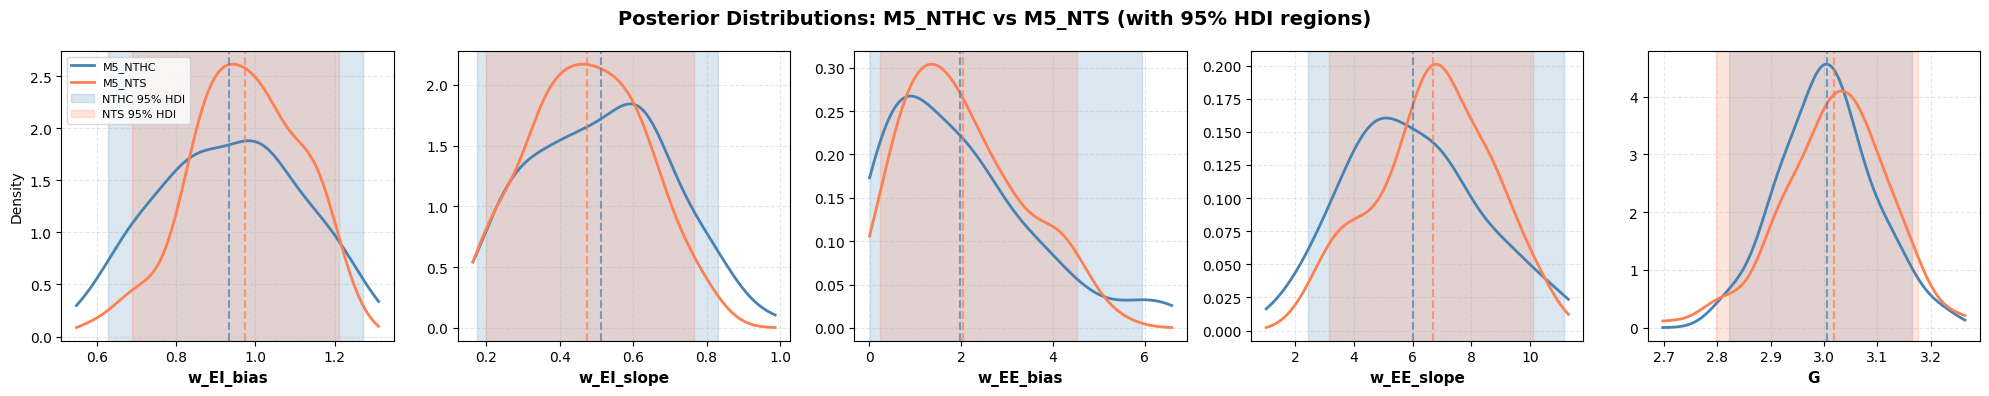

In [38]:
fig, axes = plt.subplots(1, len(param_names), figsize=(20, 4))

for i, param_name in enumerate(param_names):
    ax = axes[i]
    
    # Get parameter samples
    samples_nthc = theta_heterogeneous_M5_NTHC_hPMC[i, :]
    samples_nts = theta_heterogeneous_M5_NTS_hPMC[i, :]
    
    # Plot KDE
    from scipy.stats import gaussian_kde
    
    # Create KDE
    kde_nthc = gaussian_kde(samples_nthc)
    kde_nts = gaussian_kde(samples_nts)
    
    # Create x range
    x_min = min(samples_nthc.min(), samples_nts.min())
    x_max = max(samples_nthc.max(), samples_nts.max())
    x_range = np.linspace(x_min, x_max, 200)
    
    # Plot densities
    ax.plot(x_range, kde_nthc(x_range), label='M5_NTHC', color='steelblue', linewidth=2)
    ax.plot(x_range, kde_nts(x_range), label='M5_NTS', color='coral', linewidth=2)
    
    # Add HDI regions
    hdi_nthc = az.hdi(samples_nthc, hdi_prob=0.95)
    hdi_nts = az.hdi(samples_nts, hdi_prob=0.95)
    
    # Shade HDI regions
    ax.axvspan(hdi_nthc[0], hdi_nthc[1], alpha=0.2, color='steelblue', label='NTHC 95% HDI')
    ax.axvspan(hdi_nts[0], hdi_nts[1], alpha=0.2, color='coral', label='NTS 95% HDI')
    
    # Add mean lines
    ax.axvline(np.mean(samples_nthc), color='steelblue', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(np.mean(samples_nts), color='coral', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Formatting
    ax.set_xlabel(param_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Density' if i == 0 else '')
    ax.grid(alpha=0.3, linestyle='--')
    
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Posterior Distributions: M5_NTHC vs M5_NTS (with 95% HDI regions)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Summary: Answering the Research Question

**Question**: Is there a difference in the parameter distribution in the M5 parameter series, between the NTHC and NTS models?

**Methods Used**:
1. **Posterior Probability of Difference**: Direct calculation of P(θ_NTHC > θ_NTS | data)
   - Provides probabilistic answer to "which model has larger parameters?"
   - Values > 0.95 or < 0.05 indicate strong evidence

2. **Highest Density Interval (HDI) Comparison**: 95% credible intervals
   - Shows range of plausible parameter values
   - Non-overlapping HDIs indicate clear separation

3. **Bayesian Effect Size**: Cohen's d with uncertainty quantification
   - Small (d < 0.5), Medium (0.5 < d < 0.8), Large (d > 0.8)
   - Includes 95% HDI on effect size itself

**Interpretation Guidelines**:
- P(A > B) > 0.95: Strong evidence A > B
- P(A > B) between 0.75-0.95: Moderate evidence A > B  
- P(A > B) between 0.25-0.75: No clear difference
- Non-overlapping HDIs: Clear separation in parameter values
- Effect size interpretation follows Cohen's conventions
